### Notebook to create the figures for the modeling part of the paper [INSERT final paper]

# Setup and Helper functions

In [1]:
!pip install SciencePlots
# thanks to https://www.youtube.com/watch?v=yySQ-6mh8yo&t=4s
! sudo apt-get update
! sudo apt-get install texlive-latex-recommended
! sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended
! wget http://mirrors.ctan.org/macros/latex/...
! unzip type1cm.zip -d /tmp/type1cm<
! cd /tmp/type1cm/type1cm/ && sudo latex type1cm.ins
! sudo mkdir /usr/share/texmf/tex/latex/type1cm
! sudo cp /tmp/type1cm/type1cm/type1cm.sty /usr/share/texmf/tex/latex/type1cm
! sudo texhash
!apt install cm-super
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','nature'])
plt.rcParams.update({
    "figure.figsize": (2, 1.5)   # Label font size:25
    })          # specify font size here
from google.colab import drive
drive.mount('/content/drive')

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,878 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [61.5 kB]
Get:14 https://r2u.st

In [3]:
def process_file(filename, x_col="arc_length", y_col="nplus:0",L_REF = 1):
    """
    Load a CSV file, filter NaNs, and compute the integral of y_col over x_col.

    Parameters:
        filename (str): Path to the CSV file.
        x_col (str): Name of the column representing x-values (default: 'arc_length').
        y_col (str): Name of the column representing y-values (default: 'nplus:0').

    Returns:
        float: Computed integral, or None if an error occurs.
    """
    try:
        df = pd.read_csv(filename)

        # Drop rows with NaN values in the specified columns
        df_clean = df.dropna(subset=[x_col, y_col])

        # Extract x and y values
        x = df_clean[x_col].values*L_REF
        y = df_clean[y_col].values
        # Compute the integral using NumPy's trapezoidal rule
        integral = np.trapezoid(y, x)
        return integral

    except Exception as e:
        print(f"Error processing {filename}: {e}")
        return None

def extract_colum(filename,col):
    try:
        df = pd.read_csv(filename)

        # Drop rows with NaN values in the specified columns
        df_clean = df.dropna(subset=[col])

        # Extract x and y values
        x = df_clean[col].values

        return x

    except Exception as e:
        print(f"Error processing {filename}: {e}")
        return None



# Global Data Folder & Constants

In [4]:
FOLDER = "/content/drive/MyDrive/Projects/ Ion trapping in coated separator/Code/VoronoiFVM/Data/Output/PostProcessingOutputs/postprocessing_final_version"
OUTPUT_FOLDER = "/content/drive/MyDrive/Projects/ Ion trapping in coated separator/Manuscript/Figures"
OUTPUT_FORMAT = "png"
import os
os.path.isdir(FOLDER)


N_A = 6.02214076e23 # Avogadro constant
L_REF = 50e-9 # reference length used
K_B = 1.380649e-23 # Boltzmann constant [J/K]
T = 293.15 #Temperature [K]
E_CHARGE = 1.6020e-19 # Elementary charge [C]
PHI_REF = K_B * T / E_CHARGE


# Manuscript Figures

Figure 4 in the main manuscript

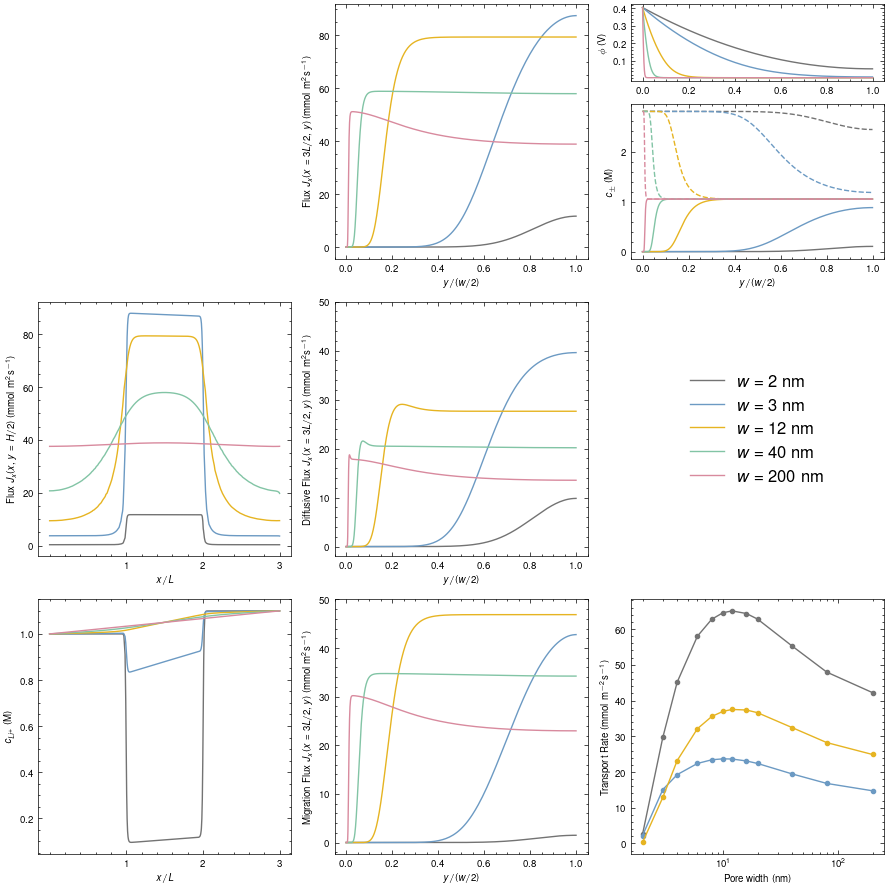

In [ ]:
# Load the necessary data
# Figure 4
fig = plt.figure(figsize = (9,9))
import matplotlib.gridspec as gridspec
gs_main = gridspec.GridSpec(3, 3, figure=fig)
# create folders for panels b) - g)
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]
legend_ax = None
# panel b)
ax = fig.add_subplot(gs_main[1,0])
legend_ax = ax
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  ax.plot(x,flux_millimol_per_meter_squared_per_second,color=colors[i],label=rf'$w = {widths[i]}$ nm')
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"Flux $J_x(x,y=H/2)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([1,2,3])

# panel c)
ax = fig.add_subplot(gs_main[2,0])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","cplus_1_per_cubic_meter")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  ax.plot(x,cplus_molar,color=colors[i])
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$c_{Li^+}$ (M)")
  ax.set_xticks([1,2,3])

# panel d)
ax = fig.add_subplot(gs_main[0,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])

# panel e)
gs_nested = gridspec.GridSpecFromSubplotSpec(
    nrows=2,
    ncols=1,
    subplot_spec=gs_main[0, 2],
    height_ratios=[1, 2],
    hspace=0.2 # Adjust space between the nested plots if needed
)
# Top 1/3 of the panel
ax_top = fig.add_subplot(gs_nested[0, 0])
ax_top.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
ax_top.set_yticks([0.1,0.2,0.3,0.4])
ax_top.set_ylabel(r"$\phi$ (V)")
# Bottom 2/3 of the panel
ax_bottom = fig.add_subplot(gs_nested[1, 0])
ax_bottom.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
ax_bottom.set_yticks([0,1,2,3])
ax_bottom.set_xlabel(r"$y/(w/2)$")
ax_bottom.set_ylabel(r"$c_{\pm}$ (M)")

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cplus_1_per_cubic_meter")
  cminus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cminus_1_per_cubic_meter")

  phi = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","phi_volt")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  # convert cminus to M
  cminus_molar = cminus/N_A/1000
  # normalize x
  x_norm = x/np.max(x)
  ax_bottom.plot(x_norm,cplus_molar,color=colors[i])
  ax_bottom.plot(x_norm,cminus_molar,'--',color=colors[i])
  ax_top.plot(x_norm,phi,color=colors[i])


# panel f)
ax = fig.add_subplot(gs_main[1,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","diff_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Diffusive Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
  ax.set_yticks([0,10,20,30,40,50])

# panel g)
ax = fig.add_subplot(gs_main[2,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","migration_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Migration Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_yticks([0,10,20,30,40,50])

# panel h)
ax = fig.add_subplot(gs_main[2,2])
# we now load all the data
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r2_nm_h16nm_l50nm",
           "/20250901_r3_nm_h24nm_l50nm",
           "/20250901_r4_nm_h32nm_l50nm",
           "/20250901_r5_nm_h40nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250901_r8_nm_h64nm_l50nm",
           "/20250901_r10_nm_h80nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250910_r40_nm_h320nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]

radii = np.array([1,1.5,2,3,4,5,6,8,10,20,40,100])
fluxes_tot = []
fluxes_diff = []
fluxes_mig = []
for (i,folder) in enumerate(folders):
  ## Total Flux
  flux_tot = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_tot_millimol_per_meter_squared_per_second = flux_tot/N_A*1000/(radii[i]*1e-9)
  fluxes_tot.append(flux_tot_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_diff = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="diff_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_diff_millimol_per_meter_squared_per_second = flux_diff/N_A*1000/(radii[i]*1e-9)
  fluxes_diff.append(flux_diff_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_mig = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="migration_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_mig_millimol_per_meter_squared_per_second = flux_mig/N_A*1000/(radii[i]*1e-9)
  fluxes_mig.append(flux_mig_millimol_per_meter_squared_per_second)

ax.plot(2*radii,fluxes_tot,'-o',color = colors[0])
ax.plot(2*radii,fluxes_diff,'-o',color = colors[1])
ax.plot(2*radii,fluxes_mig,'-o',color = colors[2])
ax.set_xscale('log')
ax.set_xlabel('Pore width (nm)')
ax.set_ylabel(r'Transport Rate (mmol m$^{-2}$s$^{-1}$)')

# legend
handles, labels = legend_ax.get_legend_handles_labels()
ax_legend = fig.add_subplot(gs_main[1, 2])
ax_legend.axis('off') # This is the crucial step to make it a clean container
ax_legend.legend(
    handles,
    labels,
    loc='center',
    fontsize=12,
    frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/Figure4.pdf")

# Supporting information Figures

## S10

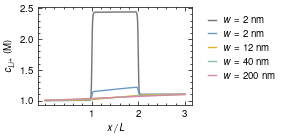

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  cminus = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","cminus_1_per_cubic_meter")
  # convert cplus to M
  cminus_molar = cminus/N_A/1000
  ax.plot(x,cminus_molar,color=colors[i])
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$c_{Li^+}$ (M)")
  ax.set_xticks([1,2,3])

ax.legend([r"$w = 2$ nm",r"$w = 2$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S10.pdf")

## S11

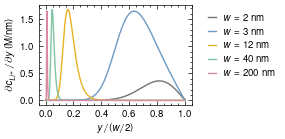

In [14]:
fig,ax = plt.subplots(figsize=(3,1.5))
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  grad_cplus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","grad_cplus_1_per_meter_to_the_4:1")
  # convert cplus to Molar/Nano/Meter
  grad_cplus_molar = grad_cplus/N_A/1000*1e-9
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,grad_cplus_molar,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"$\partial c_{Li^+}/\partial y$ (M/nm)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S11.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S11.pdf")

## S12

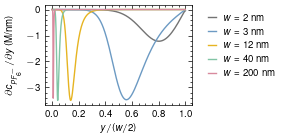

In [15]:
fig,ax = plt.subplots(figsize=(3,1.5))
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  grad_cminus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","grad_minus_1_per_meter_to_the_4:1")
  # convert cplus to Molar/NanoMeter
  grad_cminus_molar = grad_cminus/N_A/1000*1e-9
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,grad_cminus_molar,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"$\partial c_{PF_6^-}/\partial y$ (M/nm)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S12.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S12.pdf")

## S13

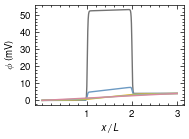

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  phi = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","phi_volt")
  # convert phi to millivolts
  phi_mV = phi*1000
  ax.plot(x,phi_mV,color=colors[i])
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$\phi$ (mV)")
  ax.set_xticks([1,2,3])
  ax.set_yticks([0,10,20,30,40,50])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S13.pdf")

## S14

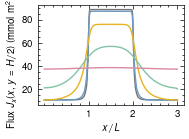

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  ax.plot(x,flux_millimol_per_meter_squared_per_second,color=colors[i],label=rf'$w = {widths[i]}$ nm')
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"Flux $J_x(x,y=H/2)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([1,2,3])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S14.pdf")

## S15

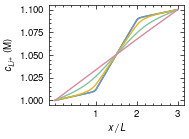

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

# panel d)
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","cplus_1_per_cubic_meter")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  ax.plot(x,cplus_molar,color=colors[i],label=rf'$w = {widths[i]}$ nm')
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$c_{Li^+}$ (M)")
  ax.set_xticks([1,2,3])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S15.pdf")

## S16

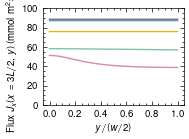

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
  ax.set_yticks([0,20,40,60,80,100])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S16.pdf")

## S17

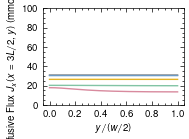

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","diff_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Diffusive Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
  ax.set_yticks([0,20,40,60,80,100])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S17.pdf")

## S18

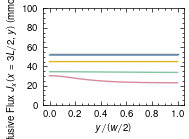

In [ ]:
fig,ax = plt.subplots(figsize=(3,1.5))
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","migration_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Diffusive Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
  ax.set_yticks([0,20,40,60,80,100])

ax.legend([r"$w = 2$ nm",r"$w = 3$ nm",r"$w = 12$ nm",r"$w = 40$ nm",r"$w = 200$ nm"],
bbox_to_anchor=(1.05, 1), loc='upper left',
handlelength=0.8,
frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S18.pdf")

## S19

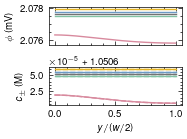

In [ ]:
fig,axs = plt.subplots(2,1,sharex=True)
# create folders for panels b) - g)
folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cplus_1_per_cubic_meter")
  cminus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cminus_1_per_cubic_meter")
  phi = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","phi_volt")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  # convert cminus to M
  cminus_molar = cminus/N_A/1000
  # convert phi to milli volt
  phi_mV = phi*1000
  # normalize x
  x_norm = x/np.max(x)
  axs[1].plot(x_norm,cplus_molar,color=colors[i])
  axs[1].plot(x_norm,cminus_molar,'--',color=colors[i])
  axs[0].plot(x_norm,phi_mV,color=colors[i])

axs[1].set_xlabel(r"$y/(w/2)$")
axs[0].set_ylabel(r"$\phi$ (mV)")
axs[1].set_ylabel(r"$c_{\pm}$ (M)")

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/S19.pdf")


## S20

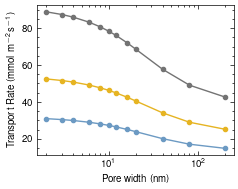

In [16]:
fig,ax = plt.subplots(figsize=(2.5,2))

folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential",
           "/20250908_r1dot5_nm_h12nm_l50nm_without_potential",
           "/20250907_r2_nm_h16nm_l50nm_without_potential",
           "/20250907_r3_nm_h24nm_l50nm_without_potential",
           "/20250907_r4_nm_h32nm_l50nm_without_potential",
           "/20250907_r5_nm_h40nm_l50nm_without_potential",
           "/20250907_r6_nm_h48nm_l50nm_without_potential",
           "/20250907_r8_nm_h64nm_l50nm_without_potential",
           "/20250905_r10_nm_h80nm_l50nm_without_potential",
           "/20250907_r20_nm_h160nm_l50nm_without_potential",
           "/20250910_r40_nm_h320nm_l50nm_without_potential",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia"]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

radii = np.array([1,1.5,2,3,4,5,6,8,10,20,40,100])
fluxes_tot = []
fluxes_diff = []
fluxes_mig = []
for (i,folder) in enumerate(folders):
  ## Total Flux
  flux_tot = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_tot_millimol_per_meter_squared_per_second = flux_tot/N_A*1000/(radii[i]*1e-9)
  fluxes_tot.append(flux_tot_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_diff = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="diff_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_diff_millimol_per_meter_squared_per_second = flux_diff/N_A*1000/(radii[i]*1e-9)
  fluxes_diff.append(flux_diff_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_mig = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="migration_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_mig_millimol_per_meter_squared_per_second = flux_mig/N_A*1000/(radii[i]*1e-9)
  fluxes_mig.append(flux_mig_millimol_per_meter_squared_per_second)

ax.plot(2*radii,fluxes_tot,'-o',color = colors[0])
ax.plot(2*radii,fluxes_diff,'-o',color = colors[1])
ax.plot(2*radii,fluxes_mig,'-o',color = colors[2])
ax.set_xscale('log')
ax.set_xlabel('Pore width (nm)')
ax.set_ylabel(r'Transport Rate (mmol m$^{-2}$s$^{-1}$)')

plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S20.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S20.pdf")

## S26

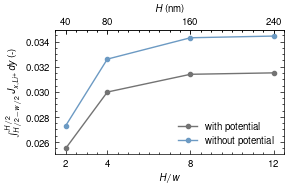

In [11]:
fig,ax = plt.subplots(figsize=(3,2))
colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

flux_20 = process_file(FOLDER + "/20250905_r10_nm_h20nm_l50nm_without_potential/" + "extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux_40 = process_file(FOLDER + "/20250905_r10_nm_h40nm_l50nm_without_potential/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux_80 = process_file(FOLDER + "/20250905_r10_nm_h80nm_l50nm_without_potential/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux_120 = process_file(FOLDER + "/20250905_r10_nm_h120nm_l50nm_without_potential/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")

flux2_20 = process_file(FOLDER + "/20251104_r10_nm_h20nm_l50nm/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux2_40 = process_file(FOLDER + "/20251104_r10_nm_h40nm_l50nm/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux2_80 = process_file(FOLDER + "/20250901_r10_nm_h80nm_l50nm/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")
flux2_120 = process_file(FOLDER + "/20250901_r10_nm_h120nm_l50nm/"+"extract_pore_center_radius_line.csv",y_col="total_flux_cplus:0")

h=np.array([20,40,80,120])
r = 10
flux_without_potential = [flux_20,flux_40,flux_80,flux_120]
flux_with_potential = [flux2_20,flux2_40,flux2_80,flux2_120]

ax.plot(h/r,flux_with_potential,'-o',color=colors[0])
ax.plot(h/r,flux_without_potential,'-o',color=colors[1])
ax.set_xlabel(r"$H/w$")
ax.set_ylabel(r"$\int_{H/2-w/2}^{H/2} J_{x,Li^+} dy$ (-)")
ax.set_xticks([2,4,8,12])

def forward(x):
    return x*r*2
def inverse(x):
    return x

secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xticks([40, 80, 160, 240])
secax.set_xlabel(r'$H$ (nm)')
ax.legend(["with potential","without potential"])

plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S26.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S26.pdf")

## S27

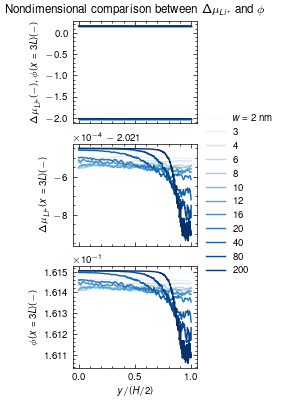

In [12]:
fig, ax = plt.subplots(3,1,figsize=(1.5,4.5),sharex=True)
folders = ["/20250901_r1_nm_h8nm_l50nm/","/20250908_r1dot5_nm_h12nm_l50nm/","/20250901_r2_nm_h16nm_l50nm/",
           "/20250901_r3_nm_h24nm_l50nm/","/20250901_r4_nm_h32nm_l50nm/","/20250901_r5_nm_h40nm_l50nm/","/20250901_r6_nm_h48nm_l50nm/",
           "/20250901_r8_nm_h64nm_l50nm/","/20250901_r10_nm_h80nm_l50nm/","/20250905_r20_nm_h160nm_l50nm/","/20250910_r40_nm_h320nm_l50nm/",
           "/20250911_r100_nm_h800nm_l50nm/"]
linetype =['-']
import matplotlib.cm as cm
import matplotlib
# Sample data: multiple sine waves with varying frequencies
num_lines = len(folders)
# Choose a colormap
colormap = matplotlib.colormaps['Blues'].resampled(num_lines)
for (i,folder) in enumerate(folders):
  color_value = i*1.0 / (num_lines - 1)
  line_color = colormap(color_value)
  h = extract_colum(FOLDER +folder +"/extract_inlet_line.csv","arc_length")
  muplus = extract_colum(FOLDER +folder+"/extract_inlet_line.csv","mu_plus")
  phi = extract_colum(FOLDER +folder+"/extract_inlet_line.csv","phi")
  h = h/max(h)
  ax[0].plot(h,muplus,linestyle = linetype[0],color = line_color)
  ax[0].plot(h,phi,linestyle = linetype[0],color = line_color)
  ax[1].plot(h,muplus,linestyle = linetype[0],color = line_color)
  ax[2].plot(h,phi,linestyle = linetype[0],color = line_color)
ax[0].ticklabel_format(axis='y', style='sci',scilimits=(0, 0))
ax[1].ticklabel_format(axis='y', style='sci',scilimits=(0, 0))
ax[2].ticklabel_format(axis='y', style='sci',scilimits=(0, 0))
ax[0].set_ylabel(r"$\Delta \mu_{Li^+} (-), \phi (x=3L) (-)$")
ax[1].set_ylabel(r"$\Delta \mu_{Li^+}(x=3L) (-)$")
ax[2].set_ylabel(r"$\phi(x=3L) (-)$")
ax[2].set_xlabel(r"$y / (H/2) $")

ax[0].set_title(r"Nondimensional comparison between $\Delta \mu_{Li^+}$ and $\phi$")
# MANUALLY adjust the subplot to make space on the right
fig.subplots_adjust(right=0.95)
# Create the legend using bbox_to_anchor
# loc='center left': Anchor the legend's 'center left' point.
# bbox_to_anchor=(1, 0.5): Place that anchor point at x=1 (right edge of figure)
#                         and y=0.5 (vertical center of figure).
ax[1].legend([r"$w$ = 2 nm","3","4","6","8","10","12","16","20","40","80","200"],loc='center left', bbox_to_anchor=(1, 0.5))

#plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S27.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S27.pdf")

##S28 (Sketch saved as PDF)

## S29

/tmp/ipython-input-3983944589.py:72: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


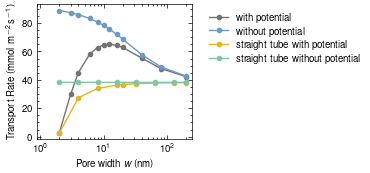

In [13]:
fig, ax = plt.subplots(figsize =(2,1.75))

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]
radii = [1,1.5,2,3,4,5,6,8,10,20,40,100]
# we load all (with potential, w/o potential, straight channel)
with_pot_folders = ["/20250901_r1_nm_h8nm_l50nm/","/20250908_r1dot5_nm_h12nm_l50nm/","/20250901_r2_nm_h16nm_l50nm/",
                    "/20250901_r3_nm_h24nm_l50nm/","/20250901_r4_nm_h32nm_l50nm/","/20250901_r5_nm_h40nm_l50nm/",
                    "/20250901_r6_nm_h48nm_l50nm/","/20250901_r8_nm_h64nm_l50nm/","/20250901_r10_nm_h80nm_l50nm/",
                    "/20250905_r20_nm_h160nm_l50nm/","/20250910_r40_nm_h320nm_l50nm/","/20250911_r100_nm_h800nm_l50nm/"]

without_pot_folders = ["/20250907_r1_nm_h8nm_l50nm_without_potential/","/20250908_r1dot5_nm_h12nm_l50nm_without_potential/",
                       "/20250907_r2_nm_h16nm_l50nm_without_potential/","/20250907_r3_nm_h24nm_l50nm_without_potential/",
                       "/20250907_r4_nm_h32nm_l50nm_without_potential/","/20250907_r5_nm_h40nm_l50nm_without_potential/",
                       "/20250907_r6_nm_h48nm_l50nm_without_potential/","/20250907_r8_nm_h64nm_l50nm_without_potential/",
                       "/20250905_r10_nm_h80nm_l50nm_without_potential/","/20250907_r20_nm_h160nm_l50nm_without_potential/",
                       "/20250910_r40_nm_h320nm_l50nm_without_potential/","/20250925_r100_nm_h800nm_l50nm_without_potentia/"]

straight_tube_radii = np.array([1,2,4,8,10,16,32,64,100])
straight_tube_folders = ["/20251208_r1_nm_h1nm_l50nm/","/20251208_r2_nm_h2nm_l50nm/",
           "/20251208_r4_nm_h4nm_l50nm/","/20251208_r8_nm_h8nm_l50nm/","/20251208_r10_nm_h10nm_l50nm/","/20251208_r16_nm_h16nm_l50nm/",
          "/20251219_r32_nm_h32nm_l50nm/","/20251208_r64_nm_h64nm_l50nm/","/20260114_r100_nm_h100nm_l50nm_with_potential/"]

straight_tube_without_pot_radii = np.array([1,2,4,8,16,32,64,100])
straight_tube_without_pot_folders = ["/20260114_r1_nm_h1nm_l50nm/","/20260114_r2_nm_h2nm_l50nm/",
           "/20260114_r4_nm_h4nm_l50nm/","/20260114_r8_nm_h8nm_l50nm/","/20260114_r16_nm_h16nm_l50nm/",
          "/20260114_r32_nm_h32nm_l50nm/","/20260114_r64_nm_h64nm_l50nm/","/20260114_r100_nm_h100nm_l50nm/"]


with_pot_fluxes = []
wihtout_pot_fluxes = []
straight_tube_fluxes = []
straight_tube_without_pot_fluxes = []

for (with_pot_folder,without_pot_folder,r) in zip(with_pot_folders,without_pot_folders,radii):
  with_pot_flux = process_file(FOLDER + with_pot_folder+"extract_pore_center_radius_line.csv",y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF=L_REF)
  wihtout_pot_flux = process_file(FOLDER + without_pot_folder+"extract_pore_center_radius_line.csv",y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF=L_REF)

  # convert flux_tot to millimol per square meter per second
  with_pot_flux_tot_millimol_per_meter_squared_per_second = with_pot_flux/N_A*1000/(r*1e-9)
  wihtout_pot_flux_tot_millimol_per_meter_squared_per_second = wihtout_pot_flux/N_A*1000/(r*1e-9)
  with_pot_fluxes.append(with_pot_flux_tot_millimol_per_meter_squared_per_second)
  wihtout_pot_fluxes.append(wihtout_pot_flux_tot_millimol_per_meter_squared_per_second)

for (straight_tube_folder,straight_tube_r) in zip(straight_tube_folders,straight_tube_radii):
  flux = process_file(FOLDER + straight_tube_folder+"extract_pore_center_radius_line.csv",y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF=L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_tot_millimol_per_meter_squared_per_second = flux/N_A*1000/(straight_tube_r*1e-9)
  straight_tube_fluxes.append(flux_tot_millimol_per_meter_squared_per_second)

for (straight_tube_folder_no_pot,straight_tube_r_no_pot) in zip(straight_tube_without_pot_folders,straight_tube_without_pot_radii):
  flux = process_file(FOLDER + straight_tube_folder_no_pot+"extract_pore_center_radius_line.csv",y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF=L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_tot_millimol_per_meter_squared_per_second = flux/N_A*1000/(straight_tube_r_no_pot*1e-9)
  straight_tube_without_pot_fluxes.append(flux_tot_millimol_per_meter_squared_per_second)

ax.plot(2*np.array(radii),np.array(with_pot_fluxes)[:],'-o',color = colors[0])
ax.plot(2*np.array(radii),np.array(wihtout_pot_fluxes)[:],'-o',color = colors[1])
ax.plot(2*np.array(straight_tube_radii),np.array(straight_tube_fluxes)[:],'-o',color = colors[2])
ax.plot(2*np.array(straight_tube_without_pot_radii),np.array(straight_tube_without_pot_fluxes)[:],'-o',color = colors[3])
ax.legend(["with potential","without potential","straight tube with potential","straight tube without potential"],bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xscale('log')
ax.set_xlim([0.9,250])
ax.set_xlabel("Pore width $w$ (nm)")
ax.set_ylabel(r'Transport Rate (mmol m$^{-2}$s$^{-1}$)')

plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S29.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S29.pdf")

## S30

/tmp/ipython-input-3254845433.py:69: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


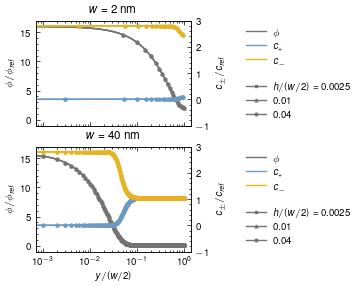

In [21]:
fig, axs = plt.subplots(2,1,figsize = (2,3),sharex=True)

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

files =[]
files.append(FOLDER + "/20251218_r20_nm_h160nm_l50nm")
files.append(FOLDER + "/20250905_r20_nm_h160nm_l50nm")
files.append(FOLDER + "/20251229_r20_nm_h160nm_l50nm_hcenterline_004")
files2 = []
files2.append(FOLDER + "/20251229_r1_nm_h8nm_l50nm_hcenterline_00025")
files2.append(FOLDER + "/20250901_r1_nm_h8nm_l50nm")
files2.append(FOLDER + "/20251229_r1_nm_h8nm_l50nm_hcenterline_004")

markers = ['s', '^', 'o']
markersize = [1.5,2,1.9]
step = 50
axs_c = axs[1].twinx()
for (file,marker,size) in zip(files,markers,markersize):
  x = extract_colum(file +"/extract_pore_center_radius_line.csv","arc_length")
  phi = extract_colum(file+"/extract_pore_center_radius_line.csv","phi")
  cplus = extract_colum(file+"/extract_pore_center_radius_line.csv","cplus")
  cminus = extract_colum(file+"/extract_pore_center_radius_line.csv","cminus")
  axs[1].plot(x/max(x),phi,linestyle='-',marker=marker,markersize = size,color = colors[0])
  axs_c.plot([-1],[-1],color = colors[0])
  axs_c.plot([-1],[-1],color = colors[1])
  axs_c.plot([-1],[-1],color = colors[2])
  axs_c.plot(x/max(x),cplus,linestyle='-',marker=marker,markersize = size,color = colors[1])
  axs_c.plot(x/max(x),cminus,linestyle='-',marker=marker,markersize = size,color = colors[2])

axs[1].set_ylim([-1,17])
axs_c.set_ylim([-1,3])
axs[1].set_xlabel(r"$y/(w/2)$")
axs[1].set_ylabel(r"$\phi/\phi_{ref}$")
axs_c.set_ylabel(r"$c_{\pm}/c_{ref}$")
axs[1].set_title(r"$w$ = 40 nm")
axs[1].legend([r'$h/(w/2) = 0.0025$',r'$0.01$',r'$0.04$'],bbox_to_anchor=(1.3, 0.5), loc='upper left')
axs_c.legend([r'$\phi$',r'$c_+$',r'$c_-$'],bbox_to_anchor=(1.3, 0.5), loc='lower left')
axs_c.set_xscale('log')


axs_c = axs[0].twinx()
for (file,marker,size) in zip(files2,markers,markersize):
  x = extract_colum(file +"/extract_pore_center_radius_line.csv","arc_length")
  phi = extract_colum(file+"/extract_pore_center_radius_line.csv","phi")
  cplus = extract_colum(file+"/extract_pore_center_radius_line.csv","cplus")
  cminus = extract_colum(file+"/extract_pore_center_radius_line.csv","cminus")
  axs[0].plot(x/max(x),phi,linestyle='-',marker=marker,markersize = size,color = colors[0],markerfacecolor='none',markevery=(0, step))
  axs_c.plot([-1],[-1],color = colors[0])
  axs_c.plot([-1],[-1],color = colors[1])
  axs_c.plot([-1],[-1],color = colors[2])
  axs_c.plot(x/max(x),cplus,linestyle='-',marker=marker,markersize = size,color = colors[1],markerfacecolor='none',markevery=(3, step))
  axs_c.plot(x/max(x),cminus,linestyle='-',marker=marker,markersize = size,color = colors[2],markerfacecolor='none',markevery=(6, step))

axs[0].set_ylim([-1,17])
axs_c.set_ylim([-1,3])
axs[0].set_ylabel(r"$\phi/\phi_{ref}$")
axs_c.set_ylabel(r"$c_{\pm}/c_{ref}$")
axs[0].legend([r'$h/(w/2) = 0.0025$',r'$0.01$',r'$0.04$'],bbox_to_anchor=(1.3, 0.5), loc='upper left')
axs_c.legend([r'$\phi$',r'$c_+$',r'$c_-$'],bbox_to_anchor=(1.3, 0.5), loc='lower left')
axs[0].set_title(r"$w$ = 2 nm")
axs_c.set_xscale('log')

plt.tight_layout()
if OUTPUT_FORMAT=='png':
  plt.savefig(OUTPUT_FOLDER + "/S30.png",dpi=300)
else:
  plt.savefig(OUTPUT_FOLDER + "/S30.pdf")

## S31

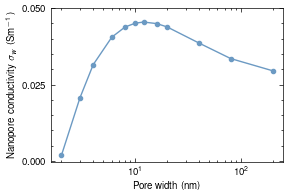

In [ ]:
fig,ax = plt.subplots(figsize=(3,2))
colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',
]
# we load all (with potential, w/o potential, straight channel)
with_pot_folders = ["/20250901_r1_nm_h8nm_l50nm/","/20250908_r1dot5_nm_h12nm_l50nm/","/20250901_r2_nm_h16nm_l50nm/",
                    "/20250901_r3_nm_h24nm_l50nm/","/20250901_r4_nm_h32nm_l50nm/","/20250901_r5_nm_h40nm_l50nm/",
                    "/20250901_r6_nm_h48nm_l50nm/","/20250901_r8_nm_h64nm_l50nm/","/20250901_r10_nm_h80nm_l50nm/",
                    "/20250905_r20_nm_h160nm_l50nm/","/20250910_r40_nm_h320nm_l50nm/","/20250911_r100_nm_h800nm_l50nm/"]

radii = [1,1.5,2,3,4,5,6,8,10,20,40,100]
with_pot_fluxes = []
DELTA_MU_DIM = []
DELTA_PHI_DIM = []


D = 2e-11
for (with_pot_folder,r) in zip(with_pot_folders,radii):
  with_pot_flux = process_file(FOLDER + with_pot_folder+"extract_pore_center_radius_line.csv",y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF=L_REF)
  with_pot_fluxes.append(with_pot_flux)
  mu_plus = extract_colum(FOLDER + with_pot_folder+"extract_along_x_center_line.csv","mu_plus")
  DELTA_MU_DIM.append((K_B*T*(mu_plus[-1]-mu_plus[0])))

  phi = extract_colum(FOLDER + with_pot_folder+"extract_along_x_center_line.csv","phi")
  DELTA_PHI_DIM.append((K_B*T*(phi[-1])))

DELTA_MU_DIM = np.array(DELTA_MU_DIM)
DELTA_PHI_DIM = np.array(DELTA_PHI_DIM)
with_pot_fluxes = np.array(with_pot_fluxes)
radii = np.array(radii)
# Scaling analysis
C_REF = 1.05*N_A*1000 # 1/m^3

sigma_estimate = C_REF*E_CHARGE**2*D/K_B/T

ax.plot(2*np.array(radii),E_CHARGE**2*np.abs(np.array(with_pot_fluxes))/DELTA_MU_DIM/(2*np.array(radii)*1e-9)*2*L_REF,'-o',color=colors[1])
#ax.plot(2*np.array(radii),E_CHARGE**2*np.abs(np.array(with_pot_fluxes))/DELTA_PHI_DIM/(2*np.array(radii)*1e-9)*6*L_REF,'-o')
#ax.plot(2*np.array(radii),np.abs(np.array(with_pot_fluxes))/(2*np.array(radii)*1e-9)*6*L_REF,'-o')

#plt.plot(2*np.array(radii),np.array(radii)/np.array(radii)*sigma_estimate,'-o')
ax.set_xscale('log')
#plt.yscale('log')
ax.set_yticks([0.0,0.025,0.05])
ax.set_xlabel(r'Pore width (nm)')
ax.set_ylabel(r'Nanopore conductivity $\sigma_w$ (Sm$^{-1}$)')

plt.savefig(OUTPUT_FOLDER + "/S31.pdf")

In [ ]:
DELTA_PHI = 0.16*K_B*T # J
MIG_FLUX = 1.35e22*100e-9 # mol/m/s
print(E_CHARGE**2*MIG_FLUX/DELTA_PHI/(2*np.array(radii)*1e-9)*2*L_REF)
print(C_REF*E_CHARGE**2*D/K_B/T)

[2.67507297 1.78338198 1.33753648 0.89169099 0.66876824 0.53501459
 0.44584549 0.33438412 0.2675073  0.13375365 0.06687682 0.02675073]
0.08019033715016054


In [ ]:
DELTA_MU_DIM

array([-9.28826727e-21, -9.28826724e-21, -9.28826722e-21, -9.28826720e-21,
       -9.28826719e-21, -9.28826719e-21, -9.28826718e-21, -9.28826716e-21,
       -9.28826715e-21, -9.28826706e-21, -9.28826697e-21, -9.28826689e-21])

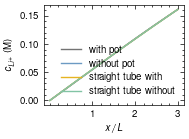

In [ ]:
fig,ax = plt.subplots()
# create folders for panels b) - g)
folders = [
           "/20250911_r100_nm_h800nm_l50nm",
           "/20250925_r100_nm_h800nm_l50nm_without_potentia",
           "/20260114_r100_nm_h100nm_l50nm_with_potential",
           "/20260114_r100_nm_h100nm_l50nm"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]

# panel d)
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","phi")
  # convert cplus to M
  ax.plot(x,cplus,color=colors[i],label=rf'$w = {widths[i]}$ nm')
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$c_{Li^+}$ (M)")
  ax.set_xticks([1,2,3])

ax.legend(["with pot","without pot","straight tube with","straight tube without"])
plt.tight_layout()
plt.savefig("out.pdf")


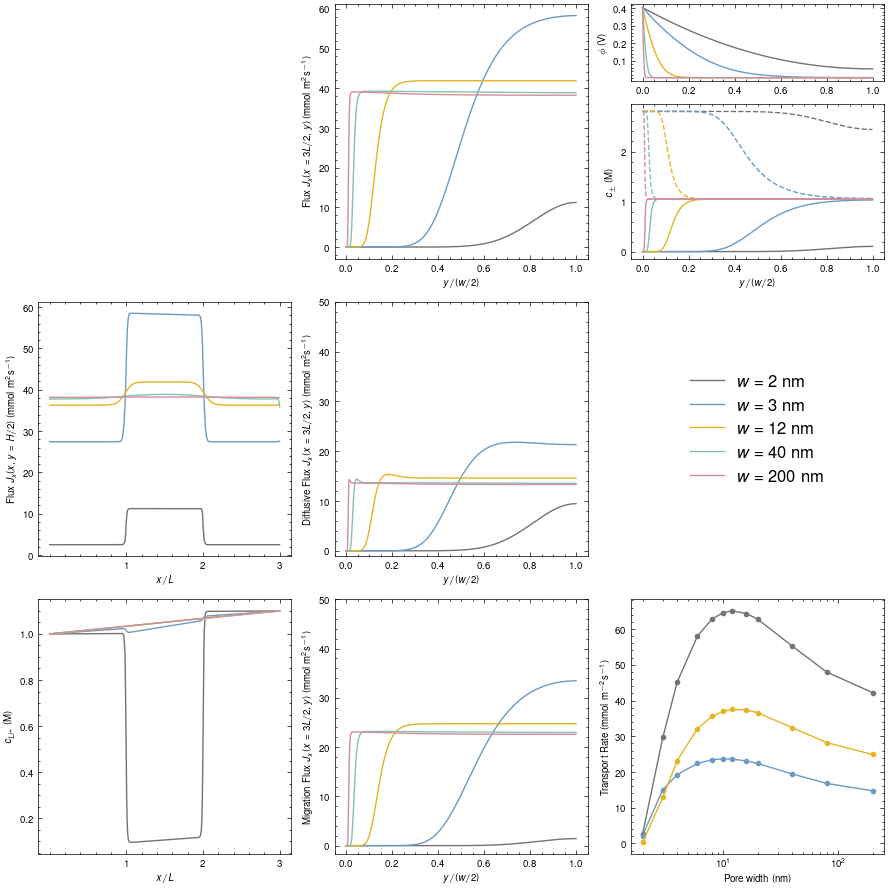

In [ ]:
# Load the necessary data
# Figure 4
fig = plt.figure(figsize = (9,9))
import matplotlib.gridspec as gridspec
gs_main = gridspec.GridSpec(3, 3, figure=fig)
# create folders for panels b) - g)
folders = ["/20251208_r1_nm_h1nm_l50nm","/20251208_r2_nm_h2nm_l50nm",
          "/20251208_r8_nm_h8nm_l50nm",
          "/20251219_r32_nm_h32nm_l50nm","/20260114_r100_nm_h100nm_l50nm_with_potential"]
widths = [2,3,12,40,200]

colors = [
    '#737373',  # Medium Gray
    '#6C9AC3',  # Muted Blue
    '#E6B422',  # Mustard Yellow
    '#82C4A5',  # Soft Green
    '#D88A9E'   # Dusty Rose
]
legend_ax = None
# panel b)
ax = fig.add_subplot(gs_main[1,0])
legend_ax = ax
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  ax.plot(x,flux_millimol_per_meter_squared_per_second,color=colors[i],label=rf'$w = {widths[i]}$ nm')
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"Flux $J_x(x,y=H/2)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([1,2,3])

# panel c)
ax = fig.add_subplot(gs_main[2,0])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_along_x_center_line.csv","cplus_1_per_cubic_meter")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  ax.plot(x,cplus_molar,color=colors[i])
  ax.set_xlabel(r"$x/L$")
  ax.set_ylabel(r"$c_{Li^+}$ (M)")
  ax.set_xticks([1,2,3])

# panel d)
ax = fig.add_subplot(gs_main[0,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","tota_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])

# panel e)
gs_nested = gridspec.GridSpecFromSubplotSpec(
    nrows=2,
    ncols=1,
    subplot_spec=gs_main[0, 2],
    height_ratios=[1, 2],
    hspace=0.2 # Adjust space between the nested plots if needed
)
# Top 1/3 of the panel
ax_top = fig.add_subplot(gs_nested[0, 0])
ax_top.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
ax_top.set_yticks([0.1,0.2,0.3,0.4])
ax_top.set_ylabel(r"$\phi$ (V)")
# Bottom 2/3 of the panel
ax_bottom = fig.add_subplot(gs_nested[1, 0])
ax_bottom.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
ax_bottom.set_yticks([0,1,2,3])
ax_bottom.set_xlabel(r"$y/(w/2)$")
ax_bottom.set_ylabel(r"$c_{\pm}$ (M)")

for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  cplus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cplus_1_per_cubic_meter")
  cminus = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","cminus_1_per_cubic_meter")

  phi = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","phi_volt")
  # convert cplus to M
  cplus_molar = cplus/N_A/1000
  # convert cminus to M
  cminus_molar = cminus/N_A/1000
  # normalize x
  x_norm = x/np.max(x)
  ax_bottom.plot(x_norm,cplus_molar,color=colors[i])
  ax_bottom.plot(x_norm,cminus_molar,'--',color=colors[i])
  ax_top.plot(x_norm,phi,color=colors[i])


# panel f)
ax = fig.add_subplot(gs_main[1,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","diff_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Diffusive Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_xticks([0,0.2,0.4,0.6,0.8,1.0])
  ax.set_yticks([0,10,20,30,40,50])

# panel g)
ax = fig.add_subplot(gs_main[2,1])
for (i,folder) in enumerate(folders):
  x = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","arc_length")
  flux = extract_colum(FOLDER +folder +"/extract_pore_center_radius_line.csv","migration_flux_cplus_1_per_meter_squared_per_second:0")
  # convert flux to millimol
  flux_millimol_per_meter_squared_per_second = flux/N_A*1000
  # normalize x
  x_norm = x/np.max(x)
  ax.plot(x_norm,flux_millimol_per_meter_squared_per_second,color=colors[i])
  ax.set_xlabel(r"$y/(w/2)$")
  ax.set_ylabel(r"Migration Flux $J_x(x = 3L/2,y)$ (mmol m$^{2}$s$^{-1}$)")
  ax.set_yticks([0,10,20,30,40,50])

# panel h)
ax = fig.add_subplot(gs_main[2,2])
# we now load all the data
folders = ["/20250901_r1_nm_h8nm_l50nm",
           "/20250908_r1dot5_nm_h12nm_l50nm",
           "/20250901_r2_nm_h16nm_l50nm",
           "/20250901_r3_nm_h24nm_l50nm",
           "/20250901_r4_nm_h32nm_l50nm",
           "/20250901_r5_nm_h40nm_l50nm",
           "/20250901_r6_nm_h48nm_l50nm",
           "/20250901_r8_nm_h64nm_l50nm",
           "/20250901_r10_nm_h80nm_l50nm",
           "/20250905_r20_nm_h160nm_l50nm",
           "/20250910_r40_nm_h320nm_l50nm",
           "/20250911_r100_nm_h800nm_l50nm"]

radii = np.array([1,1.5,2,3,4,5,6,8,10,20,40,100])
fluxes_tot = []
fluxes_diff = []
fluxes_mig = []
for (i,folder) in enumerate(folders):
  ## Total Flux
  flux_tot = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="tota_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_tot_millimol_per_meter_squared_per_second = flux_tot/N_A*1000/(radii[i]*1e-9)
  fluxes_tot.append(flux_tot_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_diff = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="diff_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_diff_millimol_per_meter_squared_per_second = flux_diff/N_A*1000/(radii[i]*1e-9)
  fluxes_diff.append(flux_diff_millimol_per_meter_squared_per_second)

  ## Diffusion Flux
  flux_mig = process_file(FOLDER + folder + "/extract_pore_center_radius_line.csv",x_col="arc_length", y_col="migration_flux_cplus_1_per_meter_squared_per_second:0",L_REF = L_REF)
  # convert flux_tot to millimol per square meter per second
  flux_mig_millimol_per_meter_squared_per_second = flux_mig/N_A*1000/(radii[i]*1e-9)
  fluxes_mig.append(flux_mig_millimol_per_meter_squared_per_second)

ax.plot(2*radii,fluxes_tot,'-o',color = colors[0])
ax.plot(2*radii,fluxes_diff,'-o',color = colors[1])
ax.plot(2*radii,fluxes_mig,'-o',color = colors[2])
ax.set_xscale('log')
ax.set_xlabel('Pore width (nm)')
ax.set_ylabel(r'Transport Rate (mmol m$^{-2}$s$^{-1}$)')

# legend
handles, labels = legend_ax.get_legend_handles_labels()
ax_legend = fig.add_subplot(gs_main[1, 2])
ax_legend.axis('off') # This is the crucial step to make it a clean container
ax_legend.legend(
    handles,
    labels,
    loc='center',
    fontsize=12,
    frameon=False # Optional: remove the legend's own frame
)
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + "/Figure4_Straight_Tube.pdf")